# Performance comparison by means of scatter plots

It is a head to head comparison of the results for the same implied bitmask, across all families and a threshold in the number of resources.

In [37]:
!pwd

/Users/wilberquito/repos/mspsp-all/mspsp-stats/notebooks/smtapi/by-time


In [38]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional
from pathlib import Path
from pprint import pprint

ROOT = Path().resolve().parent.parent.parent
print(ROOT)

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

pipe = "smtapi"

DIRS = {
    "data": {
        "wandb": DATA / "wandb" / pipe,
        "analysis": DATA / "analysis" / pipe / "instances",
    },
    "figures": FIGURES / pipe,
}

# Set working directory to the notebook's location

pprint(DIRS)

/Users/wilberquito/repos/mspsp-all/mspsp-stats
{'data': {'analysis': PosixPath('/Users/wilberquito/repos/mspsp-all/mspsp-stats/data/analysis/smtapi/instances'),
          'wandb': PosixPath('/Users/wilberquito/repos/mspsp-all/mspsp-stats/data/wandb/smtapi')},
 'figures': PosixPath('/Users/wilberquito/repos/mspsp-all/mspsp-stats/figures/smtapi')}


In [39]:
os.listdir(DIRS["data"]["wandb"])

['smtapi-MSPSP__ma_grups@f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0.csv',
 'smtapi-MSPSP__ma_grups@f=maxsat__s=evalmaxsat__i=i1=1,i2=0,i3=0,i4=0.csv',
 'smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=1.csv',
 'smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=1,i4=0.csv',
 'smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=0.csv',
 'smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=1,i2=1,i3=0,i4=0.csv',
 'smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=1,i2=0,i3=0,i4=0.csv',
 'smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=0,i2=1,i3=0,i4=0.csv',
 'smtapi-MSPSP__ma_grups@f=opb__s=exactpb__i=i1=0,i2=0,i3=1,i4=0__pb_like=0.csv',
 'smtapi-MSPSP__ma_grups@f=opb__s=roundingsat__i=i1=1,i2=1,i3=0,i4=0__pb_like=0.csv',
 'smtapi-MSPSP__ma_grups@f=opb__s=exactpb__i=i1=0,i2=0,i3=0,i4=0__pb_like=0.csv',
 'smtapi-MSPSP__ma_grups@f=opb__s=roundingsat__i=i1=0,i2=0,i3=0,i4=1__pb_like=0.csv',
 'smtapi-MSPSP__ma_grups@f=opb__s=exactpb__i=i1=0,i2=0,i3=0,i4=1__

In [40]:
instances_description_csv = f"{DIRS['data']['analysis']}/mspsp_stats.csv"
instances_description_df = pd.read_csv(instances_description_csv)
instances_description_df.shape

(1142, 10)

In [41]:
instances_description_df.head(2)

,family,n_activities,n_skills,n_resources,n_precedences,skill_factor,modified_resource_strength,network_complexity,network_density,mspsp_instance
0,set-1a,22,4,10,31,0.5,0.125,1.409091,0.134199,./modules/rcpsp-instances/MSPSP/set-1a/inst_se...
1,set-1a,22,4,10,31,0.5,0.125,1.409091,0.134199,./modules/rcpsp-instances/MSPSP/set-1a/inst_se...


In [42]:
wandb_dir = DIRS["data"]["wandb"]

df_wandb = pd.concat(
    [
        pd.read_csv(os.path.join(wandb_dir, f))
        for f in os.listdir(wandb_dir)
        if f.endswith(".csv")
    ],
    ignore_index=True,
)
df_wandb.shape

(27408, 22)

In [43]:
# Generate bitmask for implied
def add_implied_column(df: pd.DataFrame, check: bool) -> pd.DataFrame:
    # Creamos un ID único para la configuración de implied constraints

    impl_cols = [c for c in df.columns if "implied_" in c]
    df["implied_bitmask"] = df[impl_cols].apply(
        lambda x: "".join(["1" if val else "0" for val in x]), axis=1
    )

    if check:
        config_count = df["implied_bitmask"].value_counts()
        s = config_count.iloc[0]
        diff_n_count = 0
        logger: list[str] = list()

        for i, c in enumerate(config_count):
            if c != s:
                diff_n_count += 1
                logger.append(config_count.index[i])

        if diff_n_count > 0:
            print(
                f"WARNING: Configuration count mismatch: {diff_n_count} configurations have a different count than the first one"
            )
            print("Mismatched configurations:", logger)

    return df


def add_logarithmic_time(df: pd.DataFrame) -> pd.DataFrame:
    df["solver.log_real_time"] = df["solver.real_time"].apply(lambda x: np.log10(x))
    return df


def add_family_column(df: pd.DataFrame) -> pd.DataFrame:
    df["family"] = df["mspsp_instance"].apply(lambda x: x.split("/")[-2])
    return df


df_wandb = add_implied_column(df_wandb, check=True)
df_wandb = add_logarithmic_time(df_wandb)
df_wandb = add_family_column(df_wandb)

In [44]:
df_wandb.columns

Index(['Unnamed: 0', 'name', 'formalism', 'implied_1', 'implied_2',
       'implied_3', 'implied_4', 'inline_config', 'mspsp_instance', 'solver',
       'solving_timeout_s', 'encoder.real_time', 'encoder.sys_time',
       'encoder.user_time', 'makespan', 'model', 'slurm.timeout',
       'solution_status', 'solver.real_time', 'solver.sys_time',
       'solver.user_time', 'pb_like', 'implied_bitmask',
       'solver.log_real_time', 'family'],
      dtype='object')

In [45]:
df_wandb.head(2)

,Unnamed: 0,name,formalism,implied_1,implied_2,implied_3,implied_4,inline_config,mspsp_instance,solver,...,model,slurm.timeout,solution_status,solver.real_time,solver.sys_time,solver.user_time,pb_like,implied_bitmask,solver.log_real_time,family
0,0,doctor-dukat-1,maxsat,0.0,1.0,0.0,0.0,"f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0",./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,evalmaxsat,...,v S_0:0; S_1:29; S_2:0; S_3:0; S_4:9; S_5:12; ...,False,OPTIMUM_FOUND,0.33,0.00,0.25,NaN,0100,-0.481486,set-1a
1,1,ensign-quark-2,maxsat,0.0,1.0,0.0,0.0,"f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0",./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,evalmaxsat,...,v S_0:0; S_1:10; S_2:0; S_3:0; S_4:10; S_5:28;...,False,OPTIMUM_FOUND,0.11,0.01,0.10,NaN,0100,-0.958607,set-1a


In [46]:
experiments_df = (
    df_wandb[["inline_config", "implied_bitmask"]]
    .drop_duplicates()
    .sort_values("inline_config")
    .reset_index(drop=True)
)
experiments_df

,inline_config,implied_bitmask
0,"f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=0,i4=0",0000
1,"f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=0,i4=1",0001
2,"f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=1,i4=0",0010
3,"f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0",0100
4,"f=maxsat__s=evalmaxsat__i=i1=1,i2=0,i3=0,i4=0",1000
5,"f=maxsat__s=evalmaxsat__i=i1=1,i2=1,i3=0,i4=0",1100
6,"f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=0",0000
7,"f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=1",0001
8,"f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=1,i4=0",0010
9,"f=maxsat__s=maxcdcl__i=i1=0,i2=1,i3=0,i4=0",0100


In [47]:
n = len(experiments_df["inline_config"].values)


pairs = [
    (
        (
            experiments_df["inline_config"].values[i],
            experiments_df["inline_config"].values[j],
        ),
        experiments_df["implied_bitmask"].values[i],
    )
    for i in range(n)
    for j in range(i + 1, n)
    if experiments_df["implied_bitmask"].values[i]
    == experiments_df["implied_bitmask"].values[j]
]

len(pairs)

36

In [48]:
pairs[:5]

[(('f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=0,i4=0',
   'f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=0'),
  '0000'),
 (('f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=0,i4=0',
   'f=opb__s=exactpb__i=i1=0,i2=0,i3=0,i4=0__pb_like=0'),
  '0000'),
 (('f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=0,i4=0',
   'f=opb__s=roundingsat__i=i1=0,i2=0,i3=0,i4=0__pb_like=0'),
  '0000'),
 (('f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=0,i4=1',
   'f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=1'),
  '0001'),
 (('f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=0,i4=1',
   'f=opb__s=exactpb__i=i1=0,i2=0,i3=0,i4=1__pb_like=0'),
  '0001')]

In [49]:
instances_description_df["modified_resource_strength"].describe()

count    1142.000000
mean        0.068475
std         0.052282
min         0.010753
25%         0.026389
50%         0.055556
75%         0.089286
max         0.227273
Name: modified_resource_strength, dtype: float64

In [50]:
instances_description_df.shape

(1142, 10)

In [51]:
# Merge the wandb data with the instance descriptions to get family information
df_merged = pd.merge(
    df_wandb,
    instances_description_df[["mspsp_instance", "modified_resource_strength"]],
    on="mspsp_instance",
    how="inner",
)

df_merged["modified_resource_strength_bin"] = pd.cut(
    df_merged["modified_resource_strength"], bins=5
)

In [52]:
df_merged.head(2)

,Unnamed: 0,name,formalism,implied_1,implied_2,implied_3,implied_4,inline_config,mspsp_instance,solver,...,solution_status,solver.real_time,solver.sys_time,solver.user_time,pb_like,implied_bitmask,solver.log_real_time,family,modified_resource_strength,modified_resource_strength_bin
0,0,doctor-dukat-1,maxsat,0.0,1.0,0.0,0.0,"f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0",./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,evalmaxsat,...,OPTIMUM_FOUND,0.33,0.00,0.25,NaN,0100,-0.481486,set-1a,0.125,"(0.0974, 0.141]"
1,1,ensign-quark-2,maxsat,0.0,1.0,0.0,0.0,"f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0",./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,evalmaxsat,...,OPTIMUM_FOUND,0.11,0.01,0.10,NaN,0100,-0.958607,set-1a,0.125,"(0.0974, 0.141]"


In [53]:
df_merged.groupby("modified_resource_strength_bin").size().reset_index(name="count")

/var/folders/pg/qxgft6y5619fnqtqh5mq_lx00000gn/T/ipykernel_84226/373582750.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_merged.groupby("modified_resource_strength_bin").size().reset_index(name="count")


,modified_resource_strength_bin,count
0,"(0.0105, 0.0541]",13584
1,"(0.0541, 0.0974]",8712
2,"(0.0974, 0.141]",1488
3,"(0.141, 0.184]",1848
4,"(0.184, 0.227]",1776


This generates the different scatter plots comparing the performance of the different solvers. The main goal is to compare the performance of OPBVSMaxSAT with EvalMaxSAT-Exact, but we can also compare with other solvers if we want to.

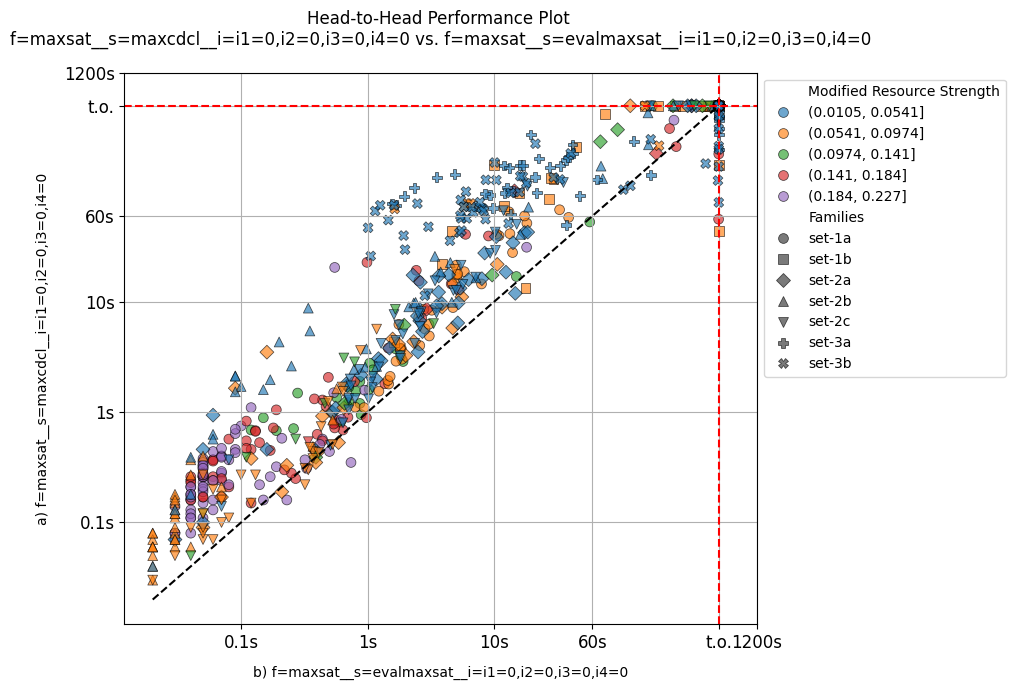

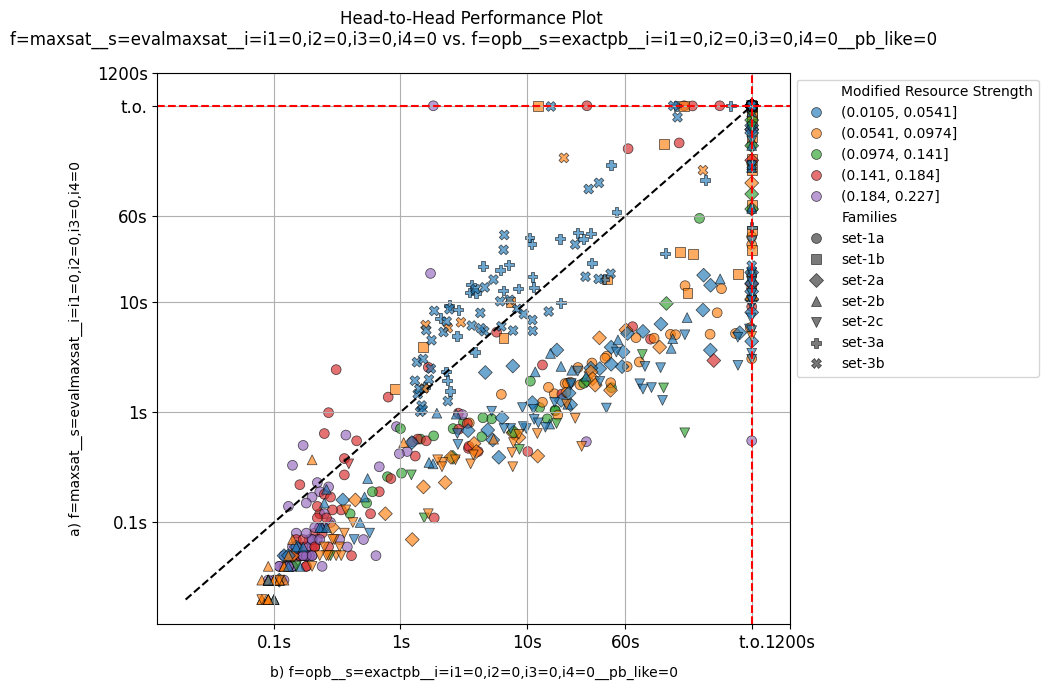

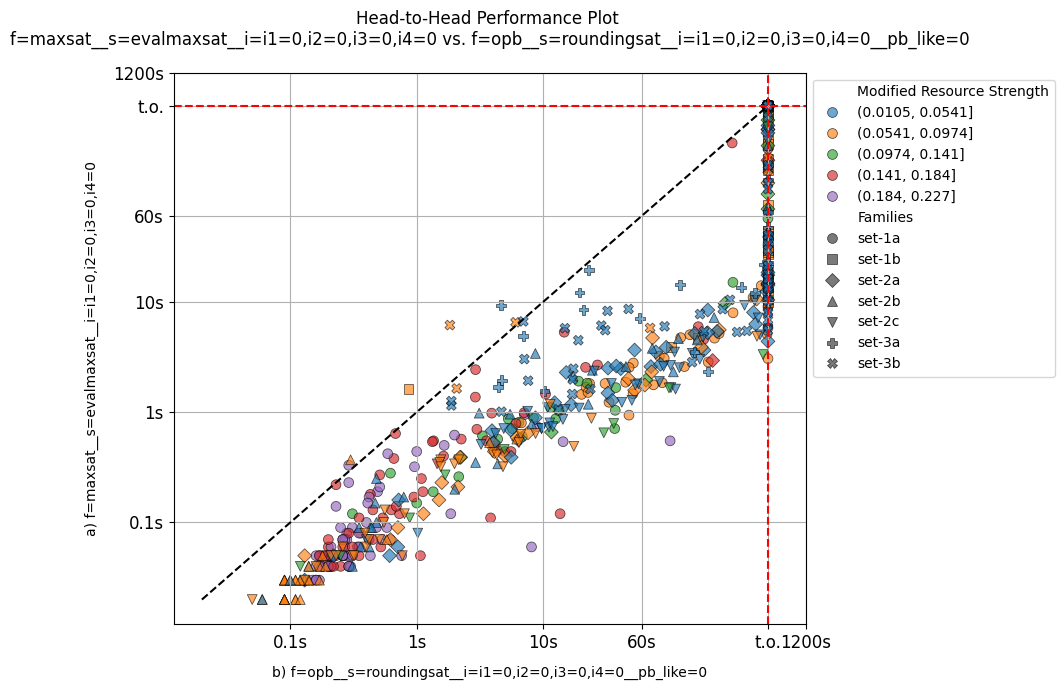

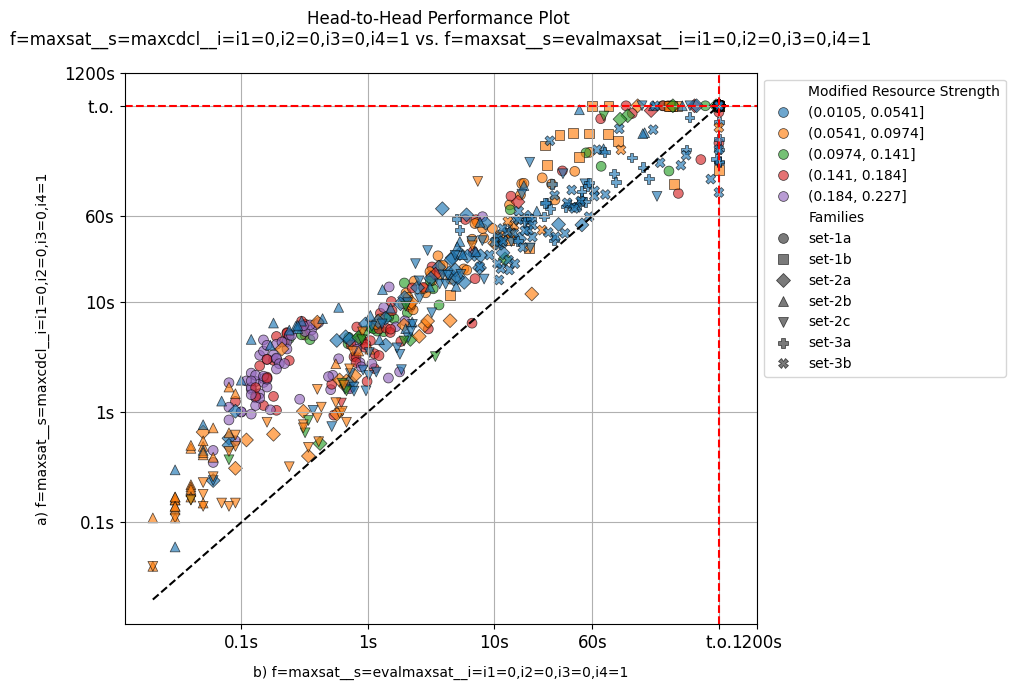

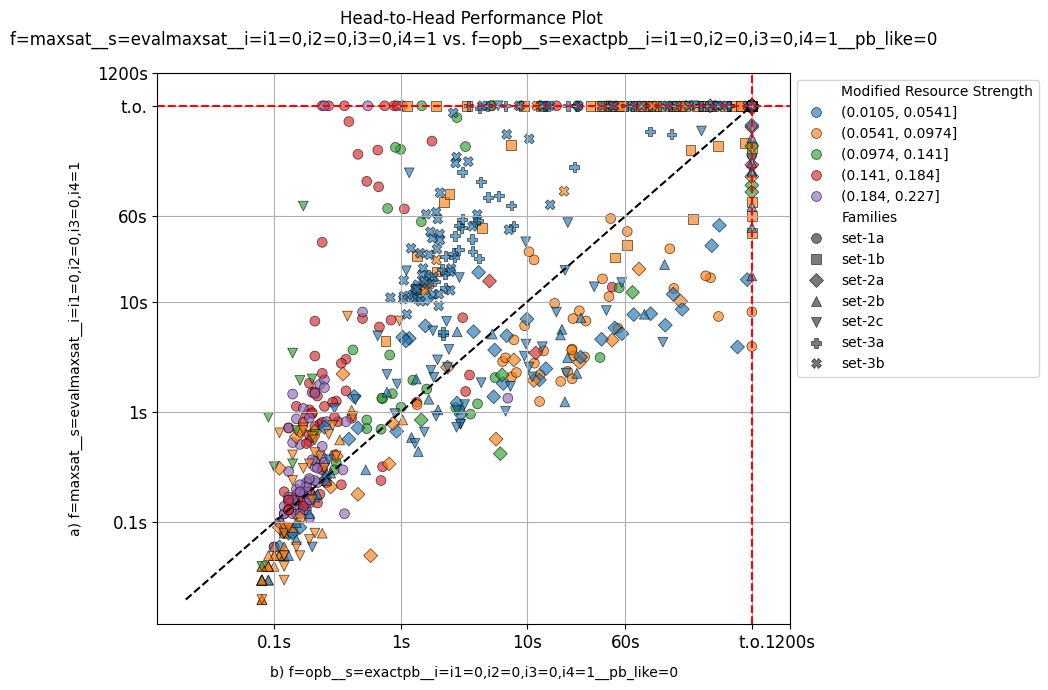

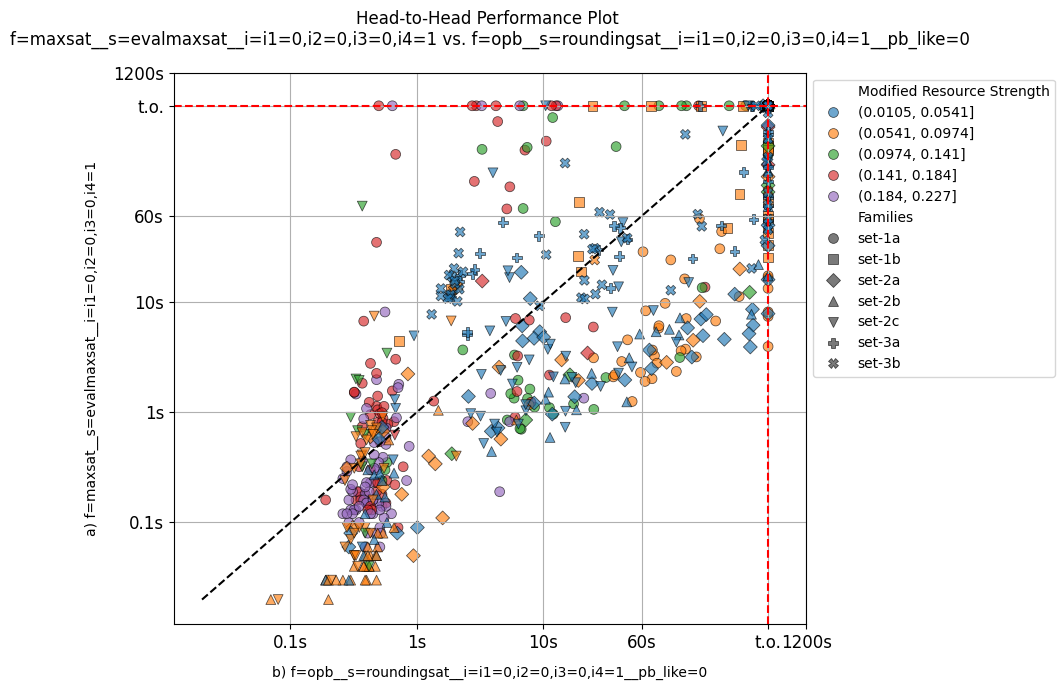

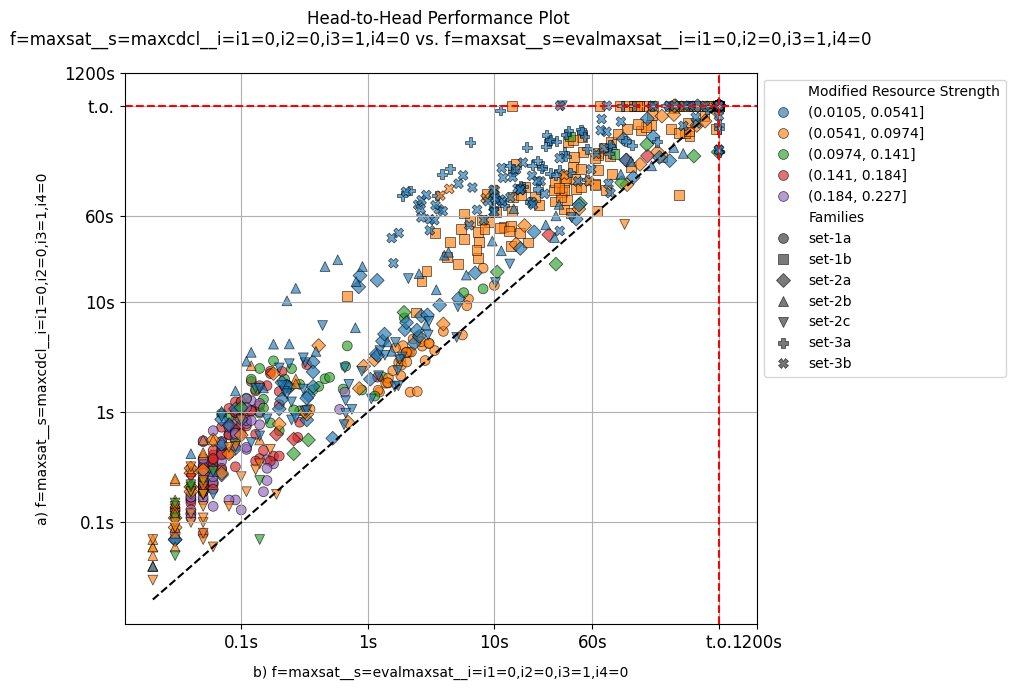

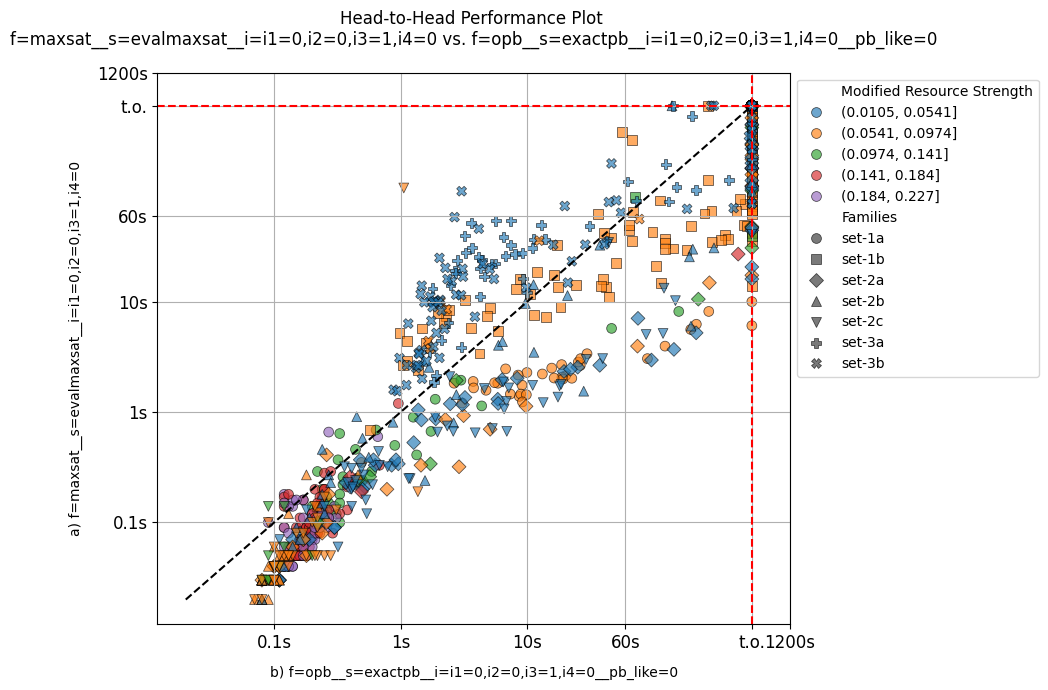

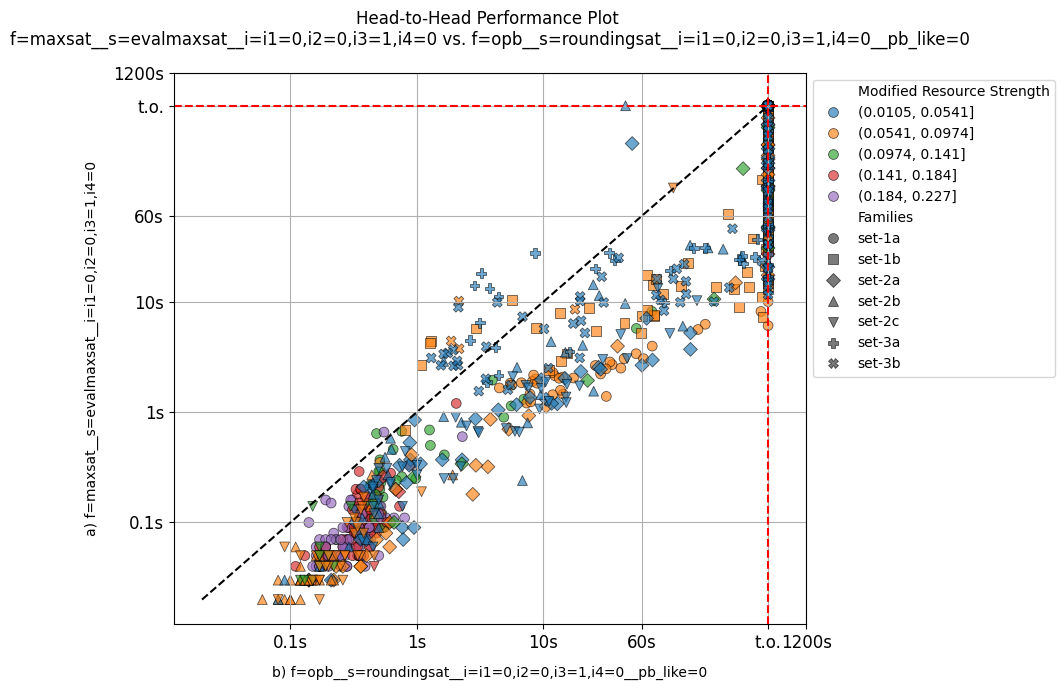

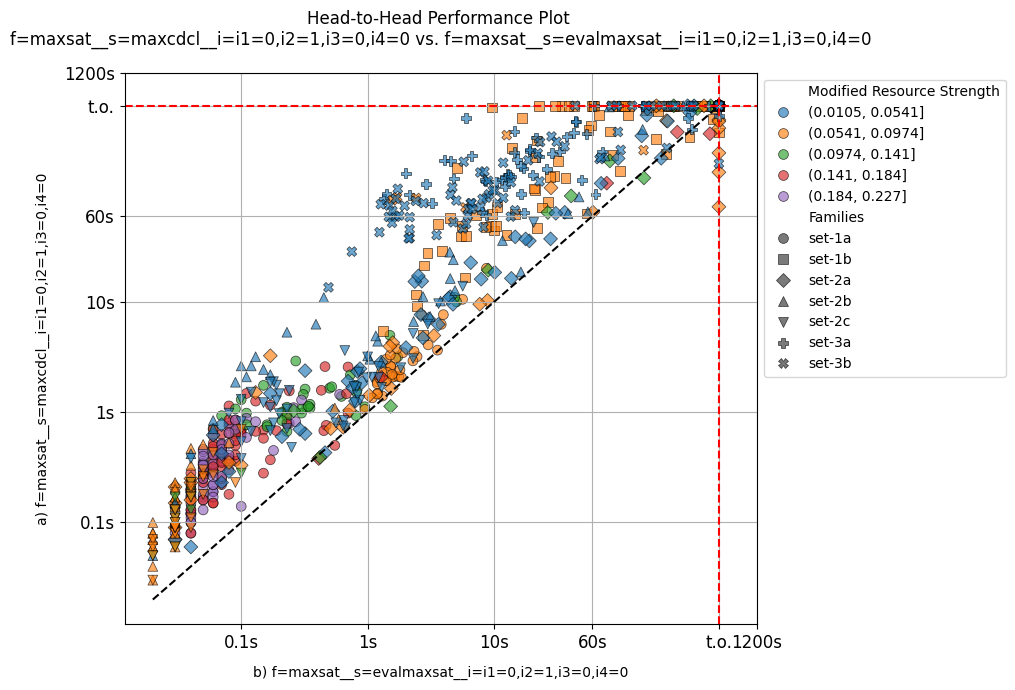

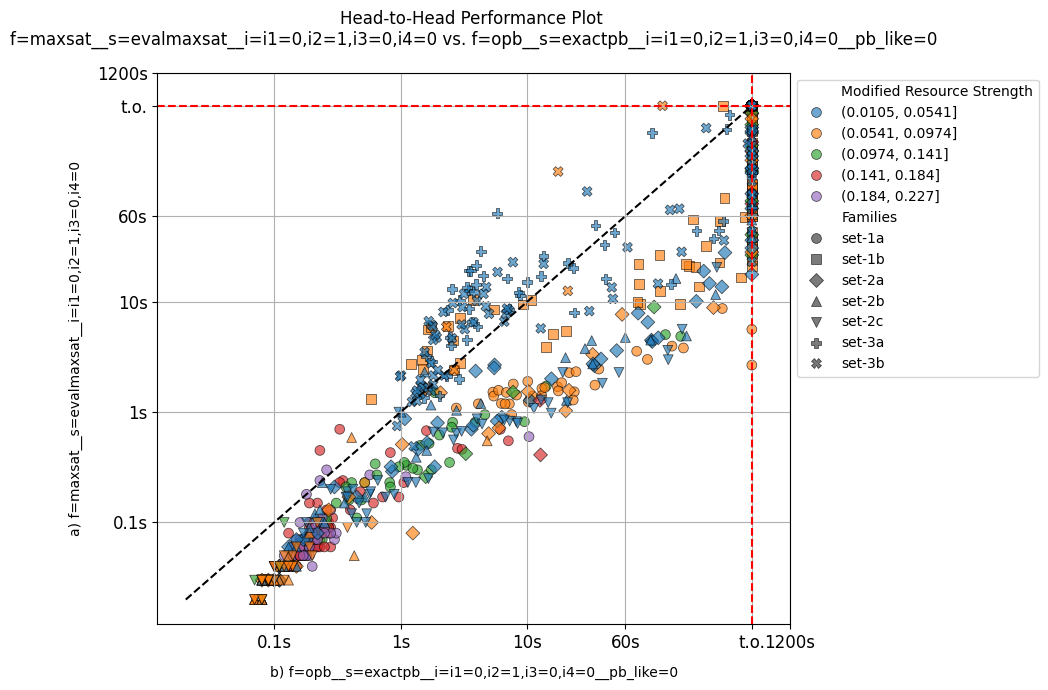

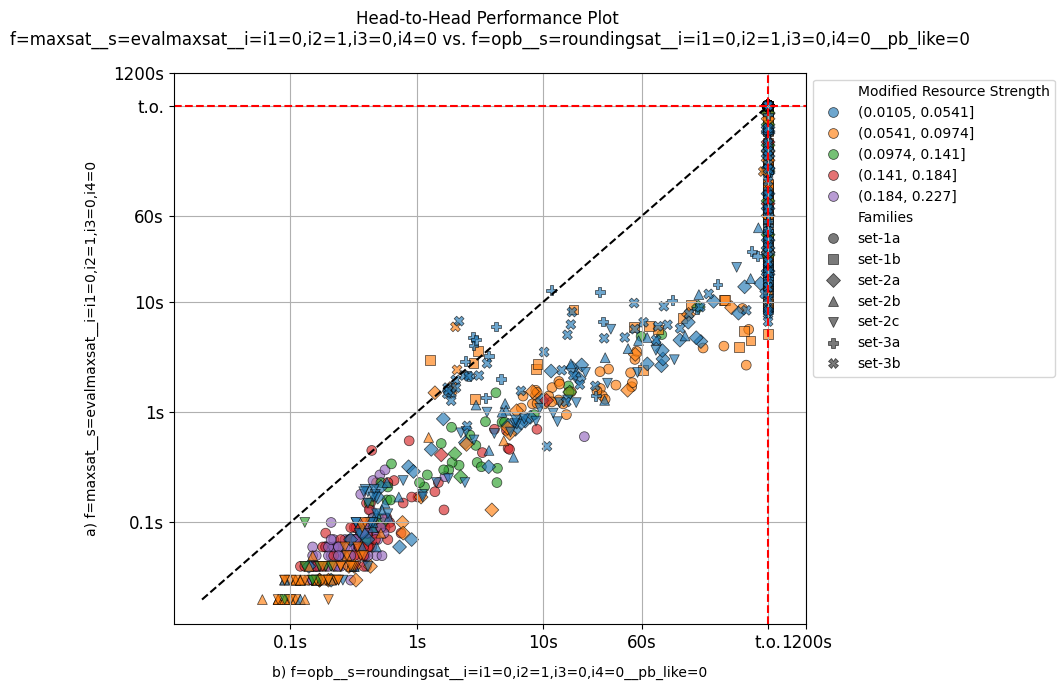

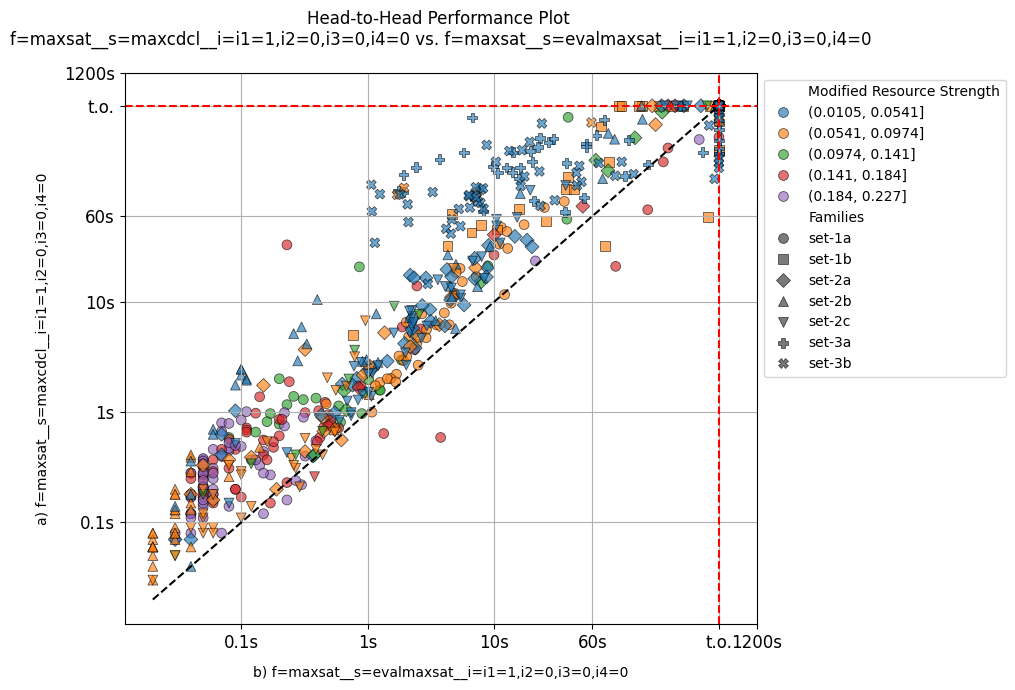

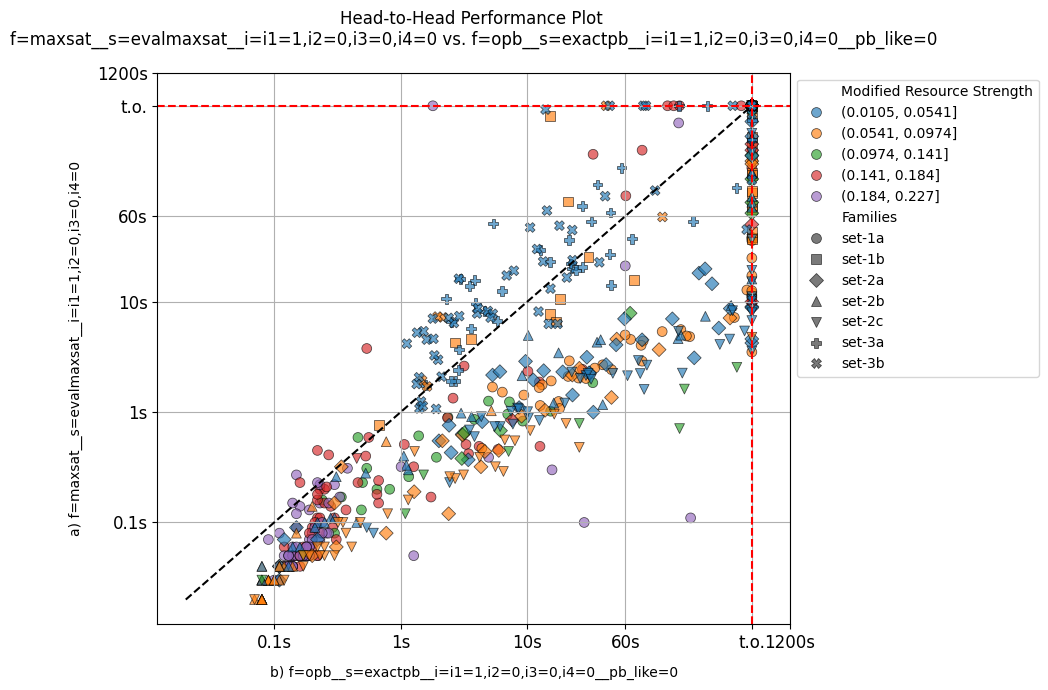

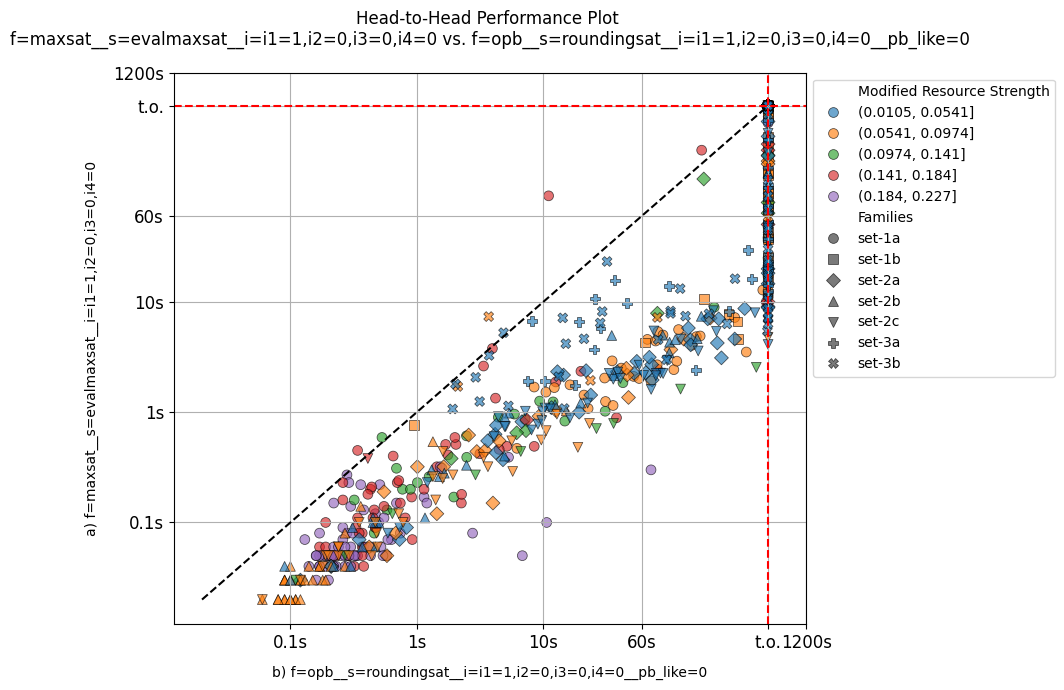

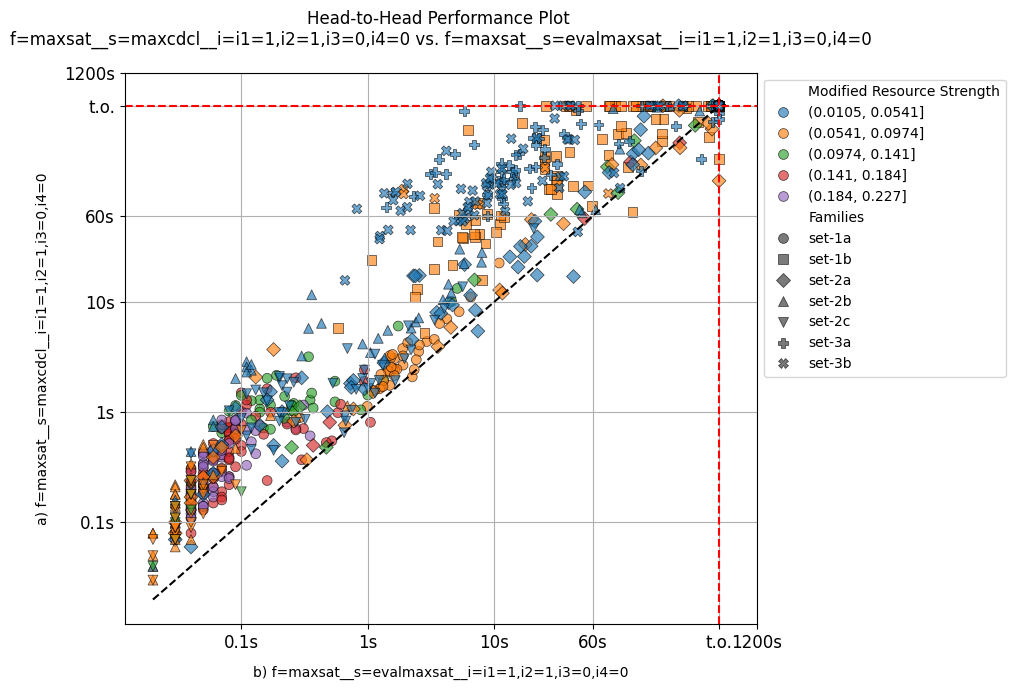

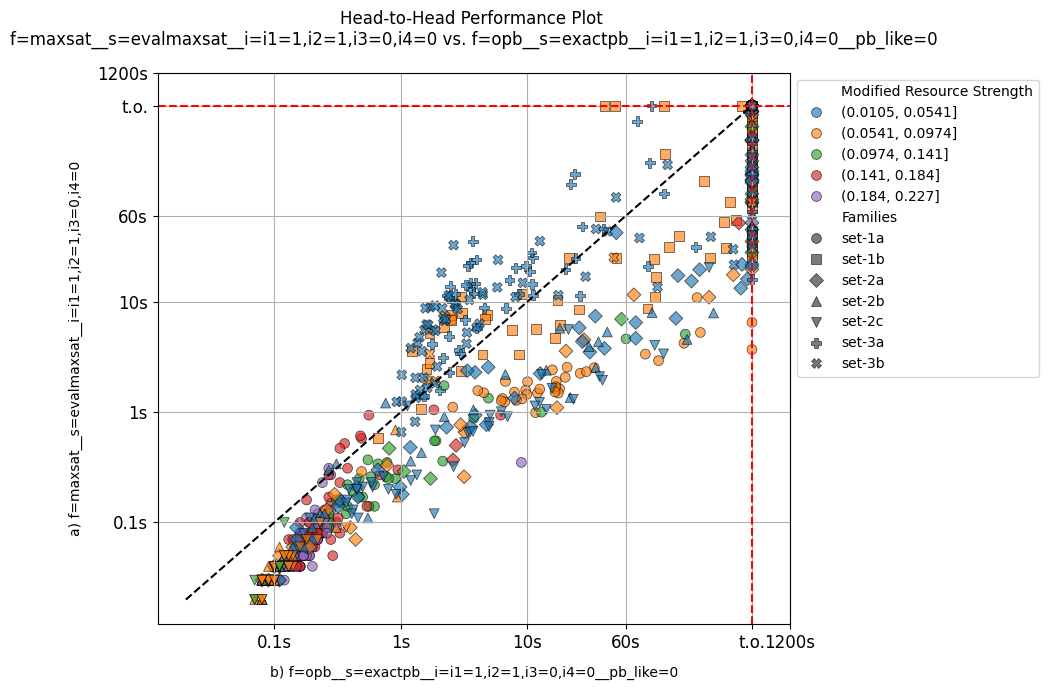

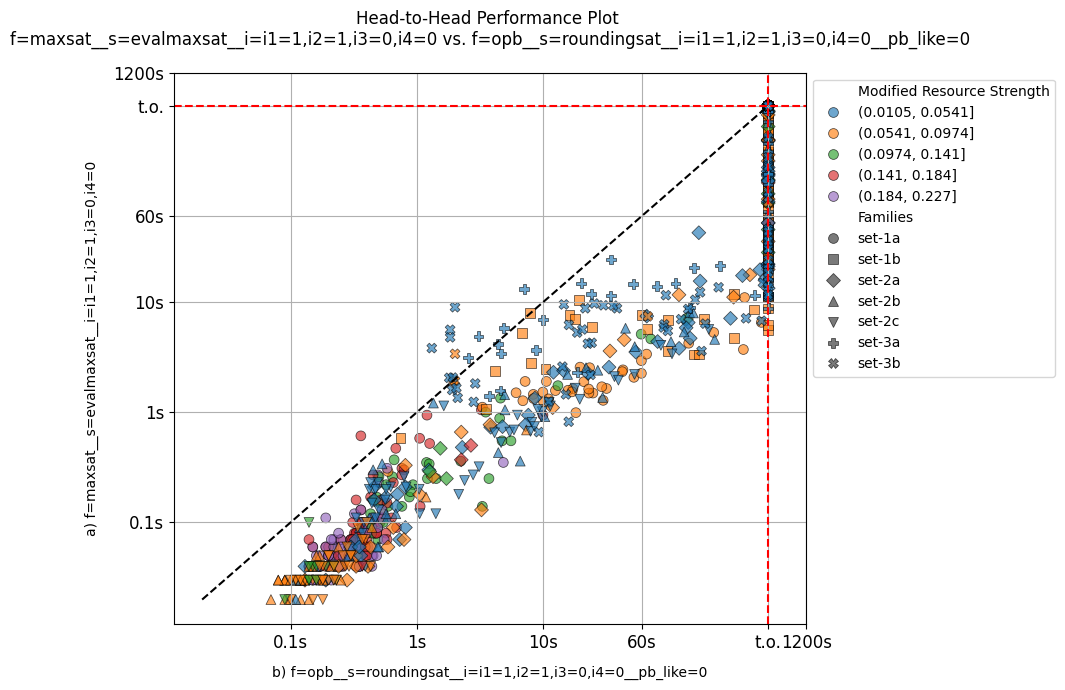

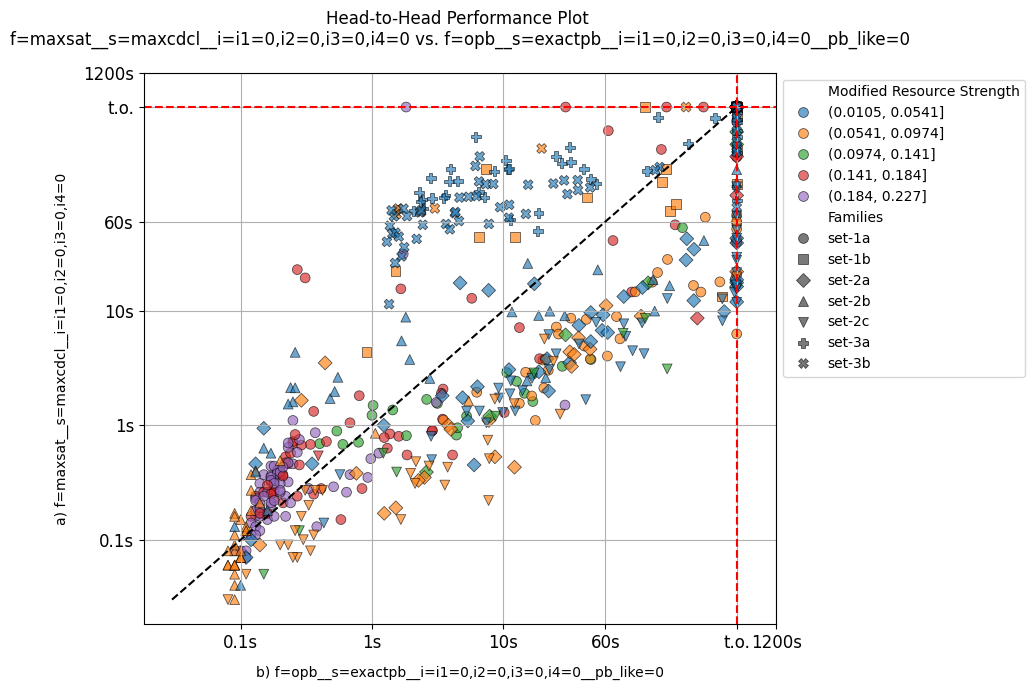

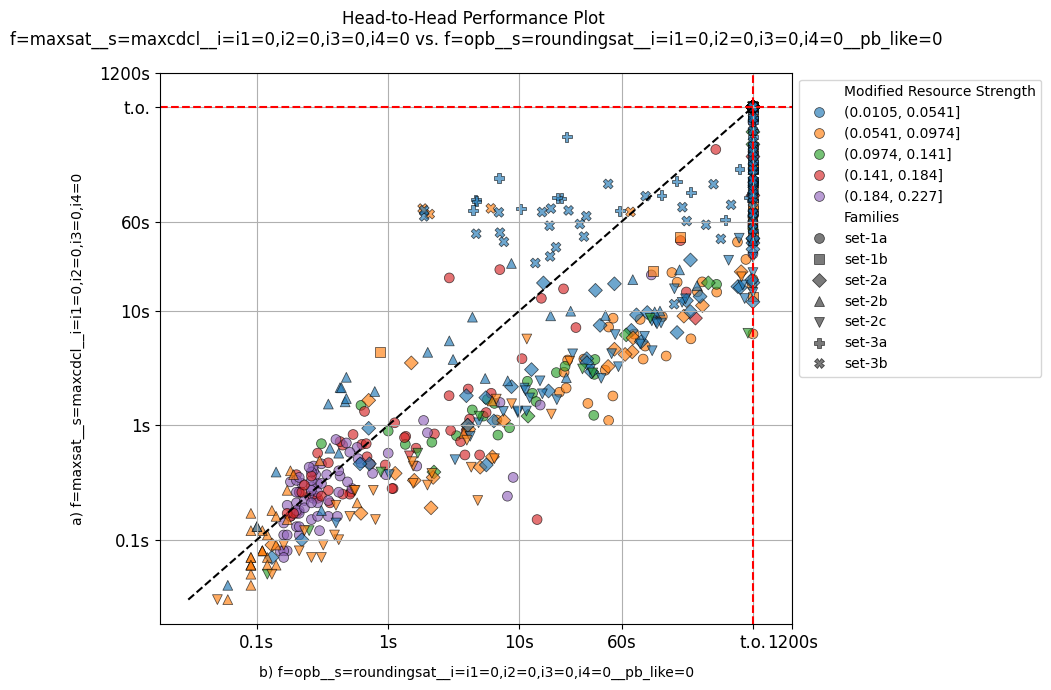

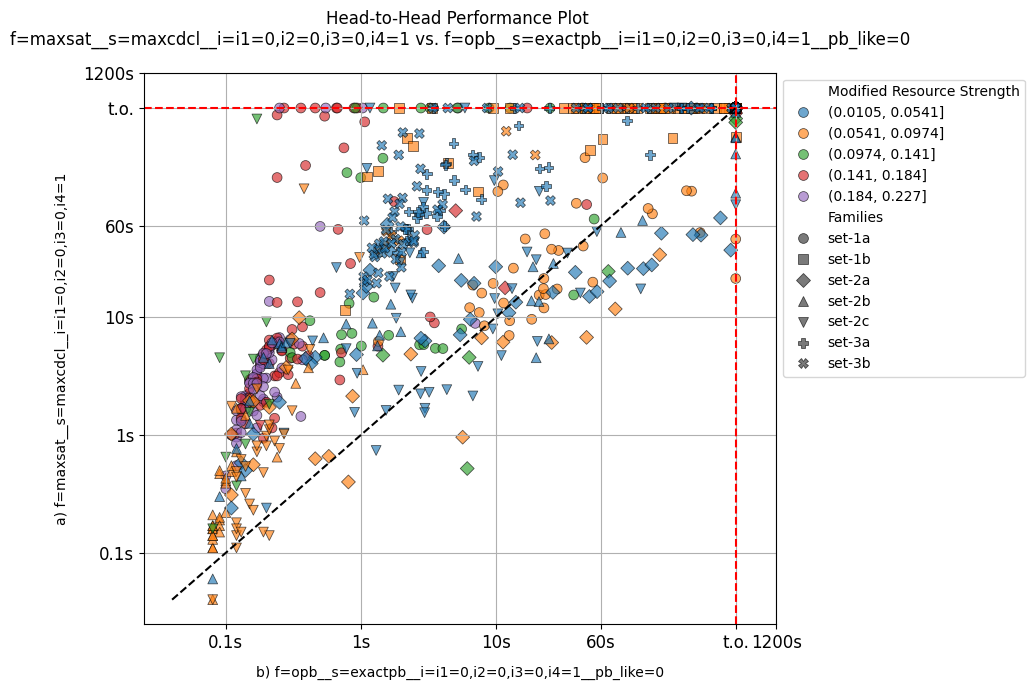

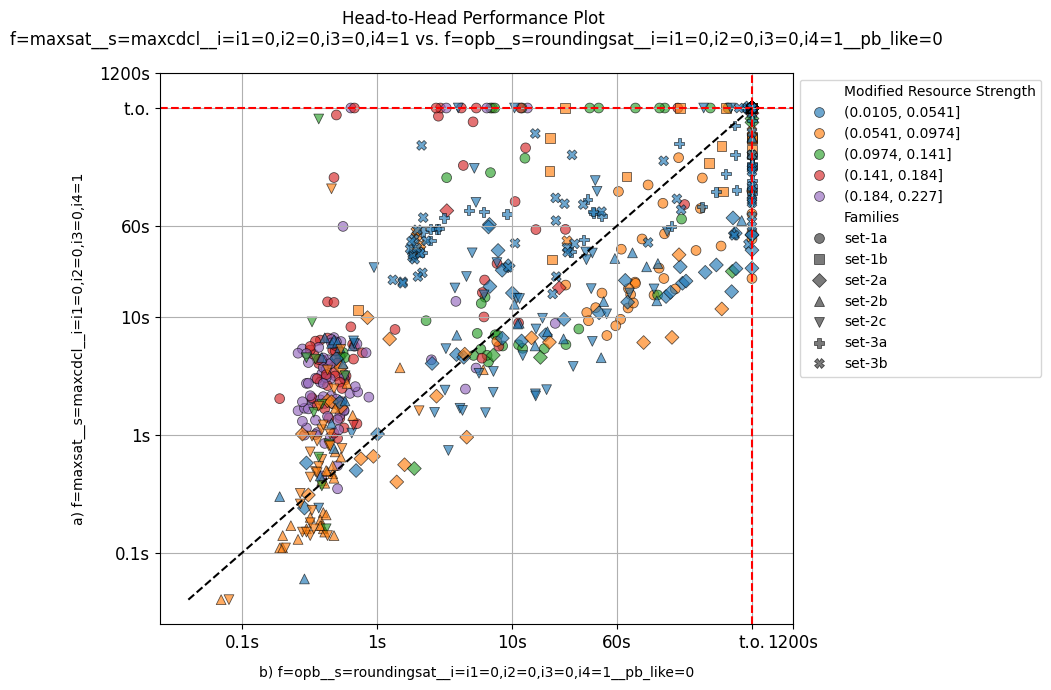

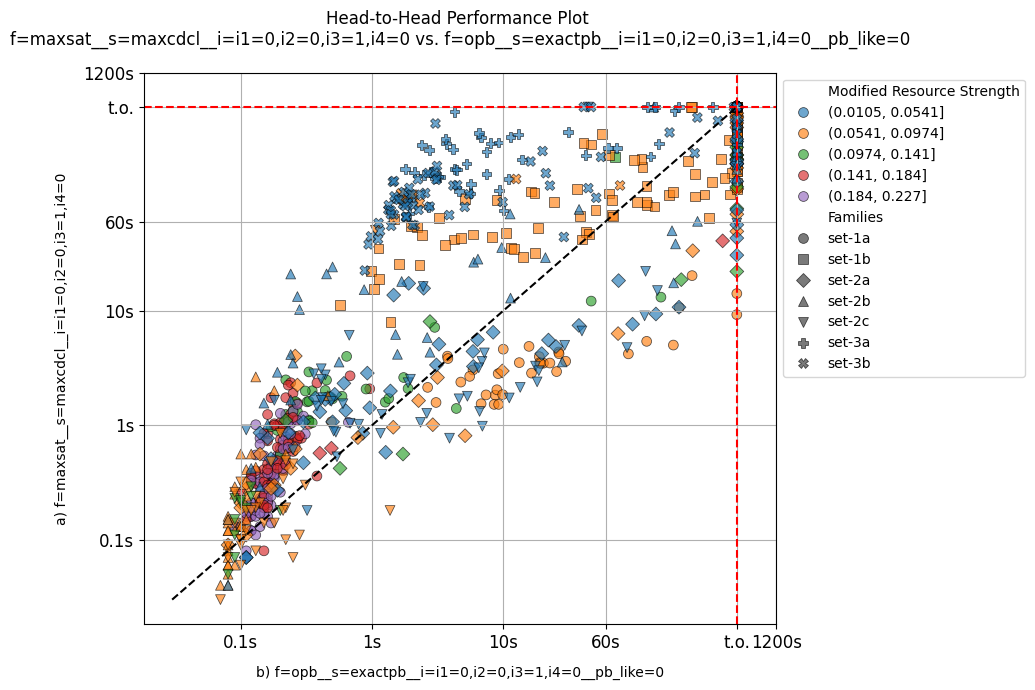

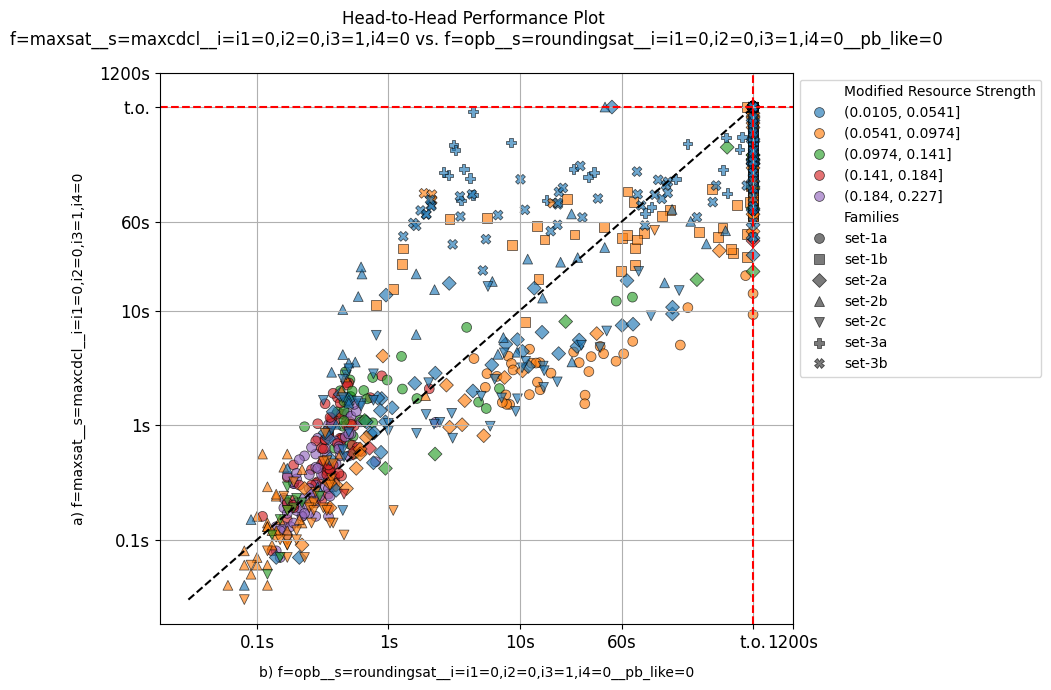

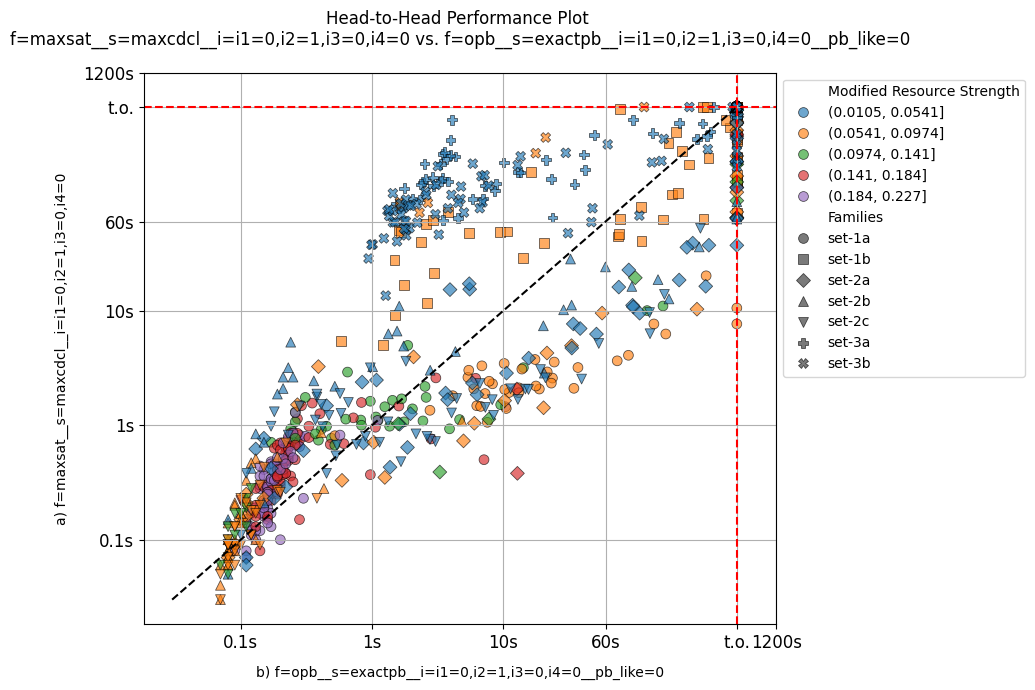

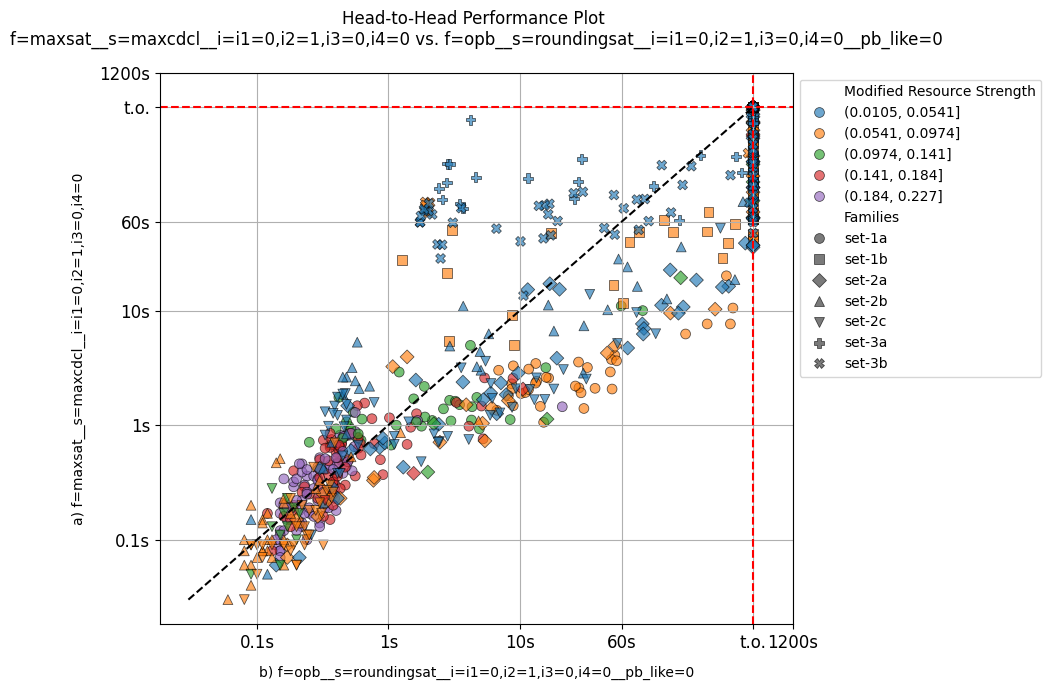

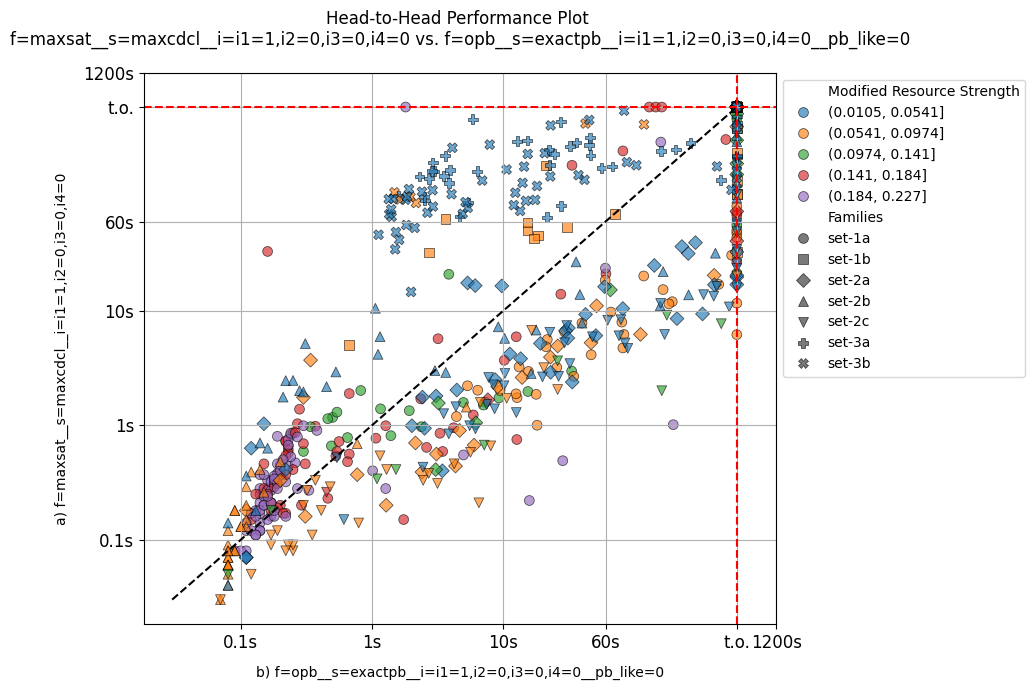

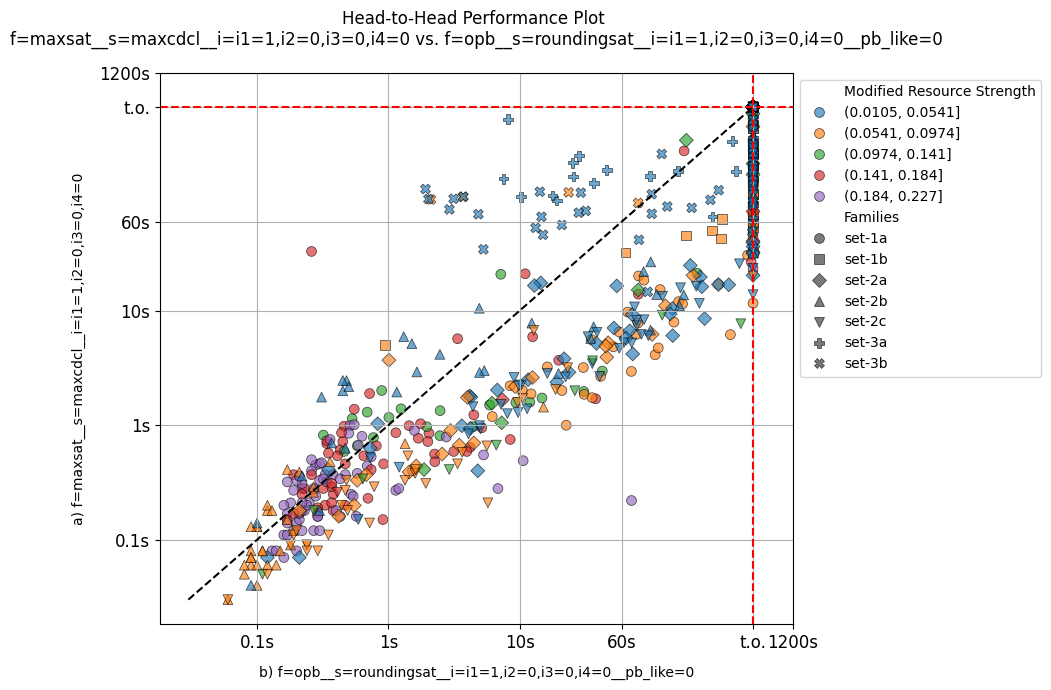

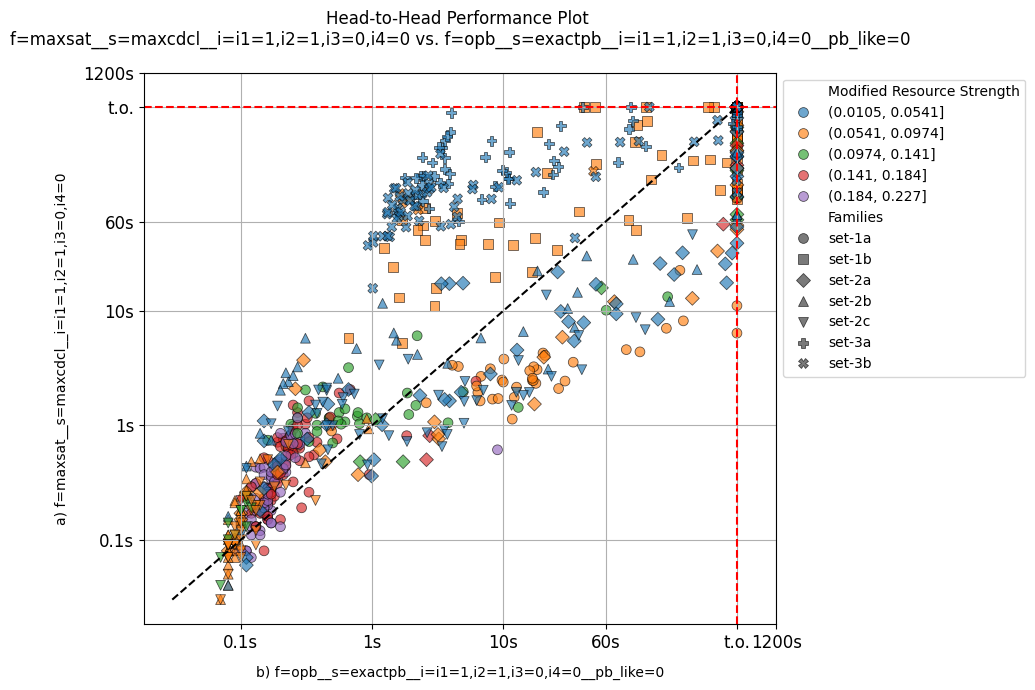

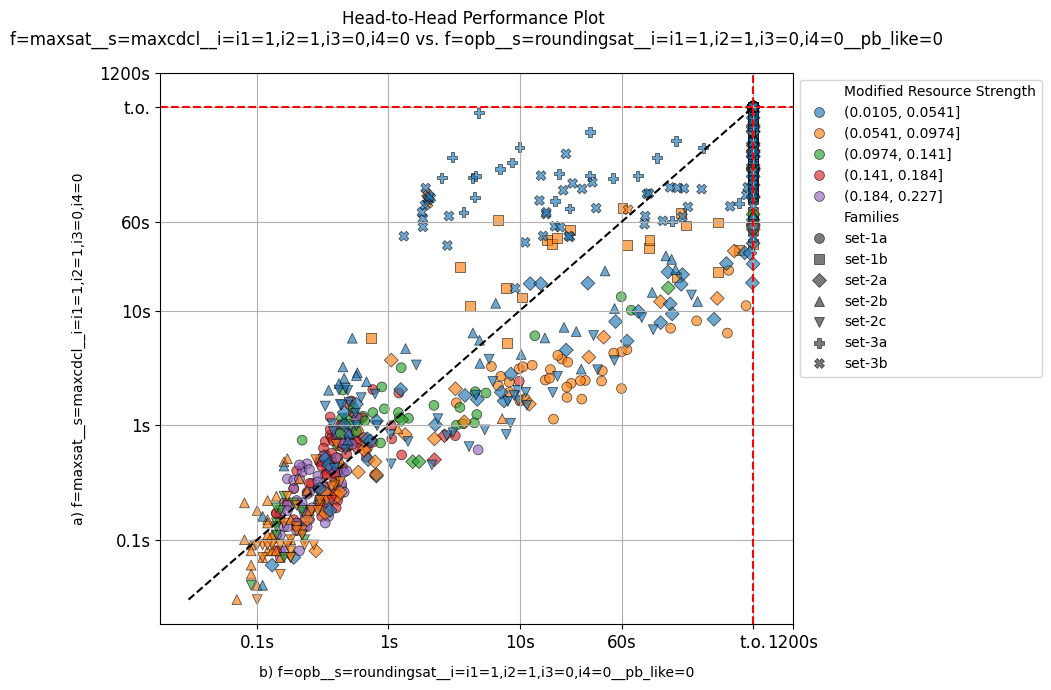

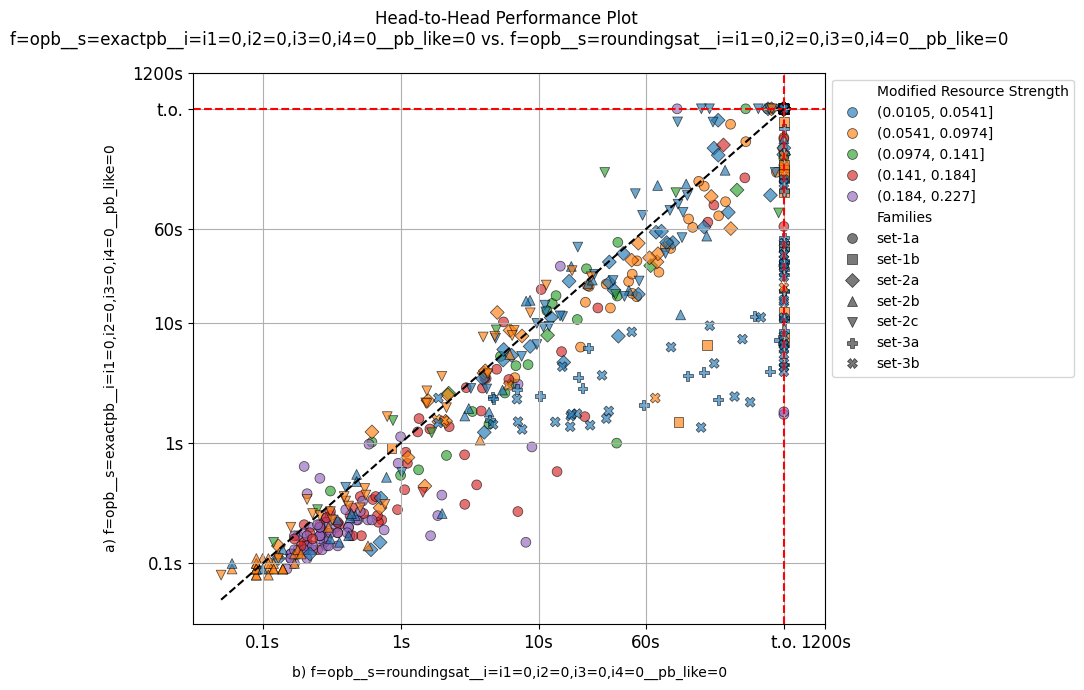

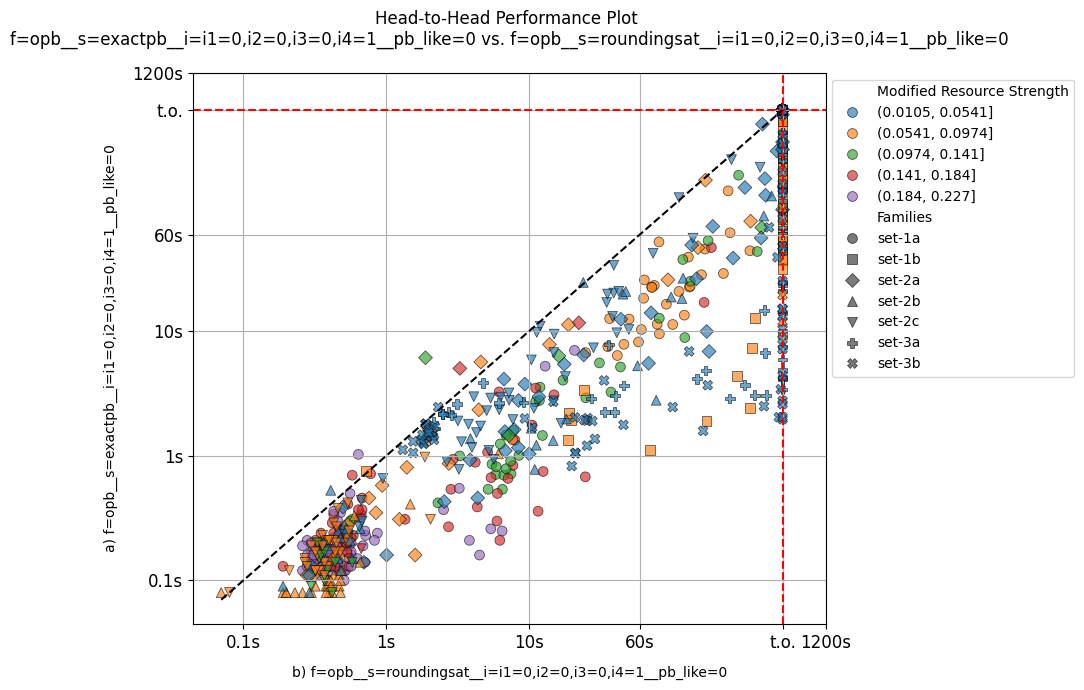

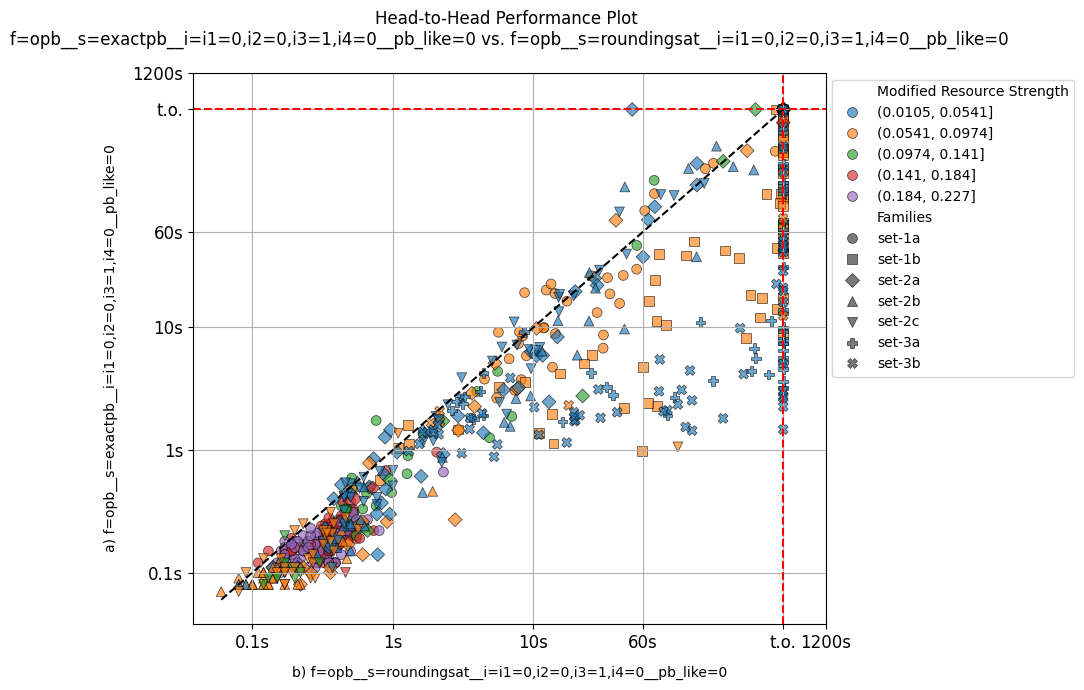

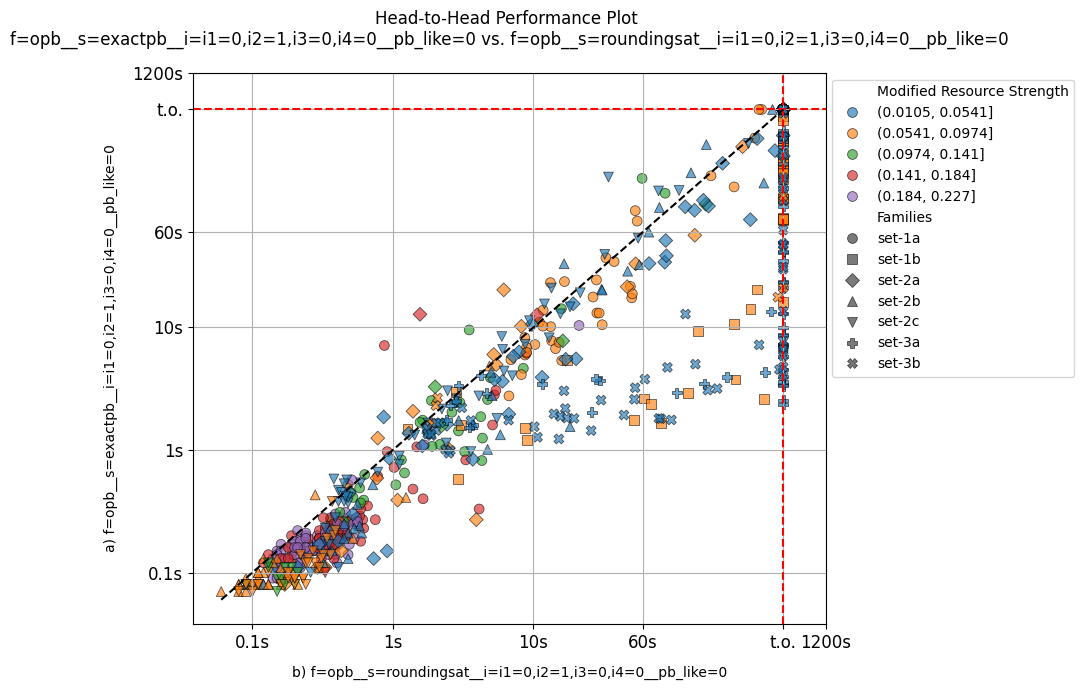

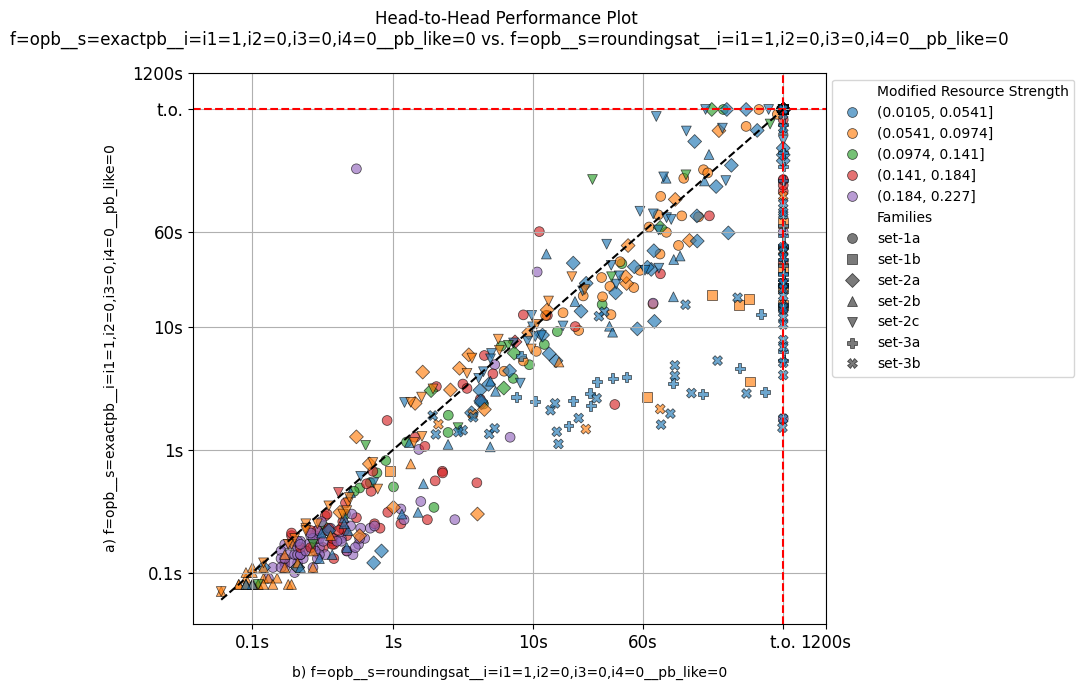

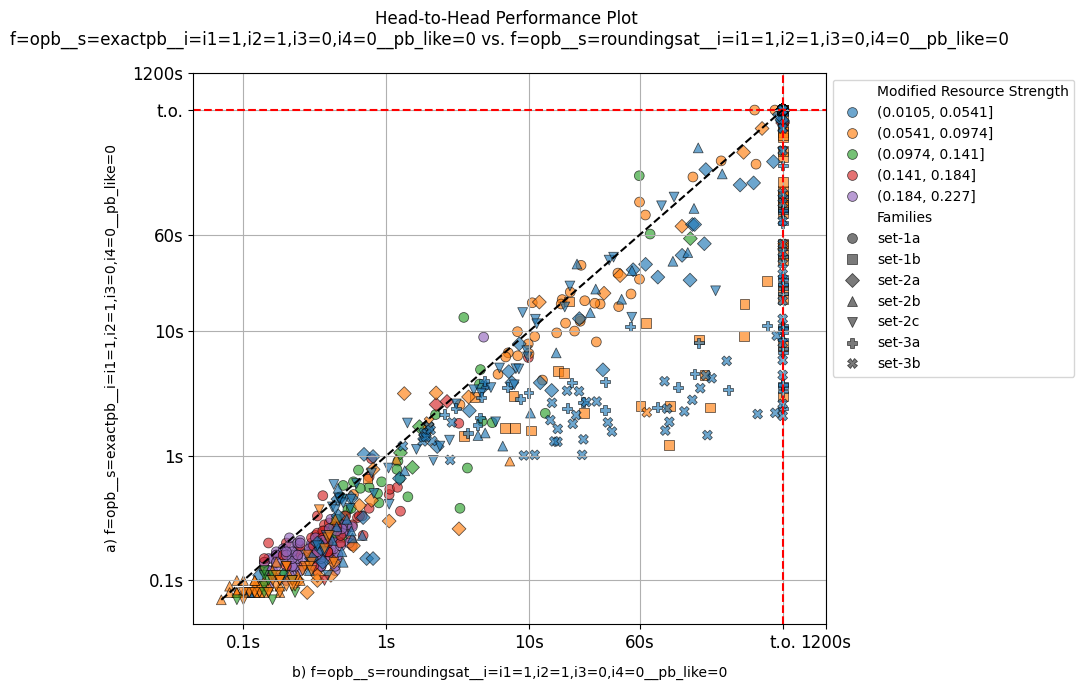

In [54]:
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

timeout = 10
log10_timeout = np.log10(timeout * 60)

for (experiment_a, experiment_b), implied_bitmask in pairs:
    plt.figure(figsize=(10, 7))

    markers7 = ["o", "s", "D", "^", "v", "P", "X"]

    if experiment_a == experiment_b:
        continue
    if "maxsat" in experiment_b:
        tmp = experiment_a
        experiment_a = experiment_b
        experiment_b = tmp

    exp_a = df_merged[df_merged["inline_config"] == experiment_a]
    exp_b = df_merged[df_merged["inline_config"] == experiment_b]

    df = pd.merge(
        exp_a,
        exp_b,
        on="mspsp_instance",
        suffixes=("_a", "_b"),
    )

    ax = sns.scatterplot(
        data=df,
        y="solver.log_real_time_a",
        x="solver.log_real_time_b",
        style="family_a",
        markers=markers7,
        hue="modified_resource_strength_bin_a",
        alpha=0.65,
        edgecolor="black",
        s=50,
    )

    plt.axhline(y=log10_timeout, color="r", linestyle="--")
    plt.axvline(x=log10_timeout, color="r", linestyle="--")

    min_val = min(
        df["solver.log_real_time_a"].min(), df["solver.log_real_time_b"].min()
    )
    max_val = max(
        df["solver.log_real_time_a"].max(), df["solver.log_real_time_b"].max()
    )
    plt.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--")

    ymin, ymax = ax.get_ylim()
    ymax = max(ymax, log10_timeout + 0.2)  # Ensure 600s is visible
    ax.set_ylim(ymin, ymax)
    ax.set_xlim(ymin, ymax)

    human_times = [0.1, 1, 10, 60, 600, 1200]
    ticks, labels = [], []
    for t in human_times:
        log_t = np.log10(t)
        ticks.append(log_t)
        labels.append(f"{t}s" if t != 600 else "t.o.")

    ax.set_yticks(ticks)
    ax.set_yticklabels(labels, fontsize=12)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, fontsize=12)

    vs = f"{experiment_a} vs. {experiment_b}"
    title = f"Head-to-Head Performance Plot \n{vs}"

    plt.title(f"{title}", pad=20)
    plt.ylabel(f"a) {experiment_a}", labelpad=10)
    plt.xlabel(f"b) {experiment_b}", labelpad=10)

    # Add them to the legend

    # # Compute your values
    # instances = len(df)
    # timeouts_a = sum(df["solver.real_time_a"] >= timeout * 60)
    # timeouts_b = sum(df["solver.real_time_b"] >= timeout * 60)

    handles, labels = ax.get_legend_handles_labels()

    # # 2. Create "Simple" text markers for your timeout counts
    # # We use Line2D with linestyle='None' so only the marker (the letter) shows up
    # extra_handles = [
    #     Line2D(
    #         [0],
    #         [0],
    #         marker="$a$",
    #         color="black",
    #         linestyle="None",
    #         markersize=8,
    #         label=f"{timeouts_a} timeouts",
    #     ),
    #     Line2D(
    #         [0],
    #         [0],
    #         marker="$b$",
    #         color="black",
    #         linestyle="None",
    #         markersize=9,
    #         label=f"{timeouts_b} timeouts",
    #     ),
    # ]

    # extra_handles = [
    #     Line2D(
    #         [0], [0], marker="None", linestyle="None", label=f"a timeouts: {timeouts_a}"
    #     ),
    #     Line2D(
    #         [0], [0], marker="None", linestyle="None", label=f"b timeouts: {timeouts_b}"
    #     ),
    # ]

    # handles.extend(extra_handles)
    # labels.extend([f"{timeouts_a} timeouts", f"{timeouts_b} timeouts"])

    legend = plt.legend(
        handles,
        labels,
        bbox_to_anchor=(1, 1),
        loc="upper left",
    )

    # legend.set_title("Legend", prop={"size": 11})

    for text in legend.texts:
        if text.get_text() == "modified_resource_strength_bin_a":
            text.set_text("Modified Resource Strength")
        elif text.get_text() == "family_a":
            text.set_text("Families")

    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            DIRS["figures"],
            "head-to-head",
            implied_bitmask,
            "mrs",
            f"{vs}.png",
        ),
        dpi=300,
        transparent=True,
    )

    plt.show()